In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from huggingface_hub import HfApi

api = HfApi()
files = api.list_repo_files("open-spaced-repetition/fsrs-dataset", repo_type="dataset")
parquet_files = [f for f in files if f.endswith(".parquet")]
print(parquet_files)

[]


In [ ]:
files = api.list_repo_files("open-spaced-repetition/fsrs-dataset", repo_type="dataset", revision="refs/convert/parquet")
print(files)


['.gitattributes', 'default/train/0000.parquet', 'default/train/0001.parquet', 'default/train/0002.parquet', 'default/train/0003.parquet', 'default/train/0004.parquet']


In [ ]:
#get a shard of the whole data
pool = pd.read_parquet(
    "hf://datasets/open-spaced-repetition/fsrs-dataset@refs/convert/parquet/default/train/0000.parquet"
)

print(f"Loaded {len(pool):,} rows")
print(f"{pool['card_id'].nunique():,} unique cards")
print(pool.columns.tolist())
pool.head()

Loaded 3,249,801 rows
317,819 unique cards
['review_time', 'card_id', 'i', 'delta_t', 'review_rating', 'y', 't_history', 'r_history']


,review_time,card_id,i,delta_t,review_rating,y,t_history,r_history
0,1631735593296,1630607654030,1,0.0000,3,1,None,None
1,1631959760796,1630607654030,2,2.5945,3,1,0.0,3
2,1633523989442,1630607654030,3,18.1045,3,1,"0.0,2.5945","3,3"
3,1650729793746,1630607654030,4,199.1413,3,1,"0.0,2.5945,18.1045","3,3,3"
4,1631439488664,1630607654032,1,0.0000,3,1,None,None


In [ ]:
#need to know when y=1 is this the rembemred or forgot
pool.groupby("review_rating")["y"].mean()

,y
review_rating,
1,0.0
2,1.0
3,1.0
4,1.0


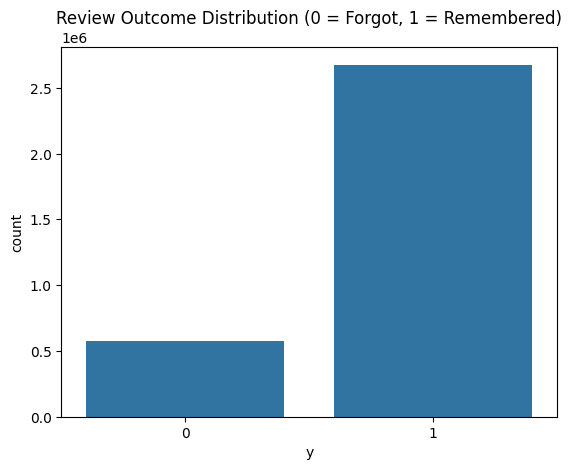

y
1    82.3
0    17.7
Name: proportion, dtype: float64


In [ ]:
sns.countplot(x='y', data=pool)
plt.title("Review Outcome Distribution (0 = Forgot, 1 = Remembered)")
plt.show()

print(pool['y'].value_counts(normalize=True).round(3) * 100)

**Confirmed:** `review_rating = 1` → `y = 0` (forgot); ratings 2–4 → `y = 1` (remembered). So `needs_review = 1 - y` is a valid target derivation.

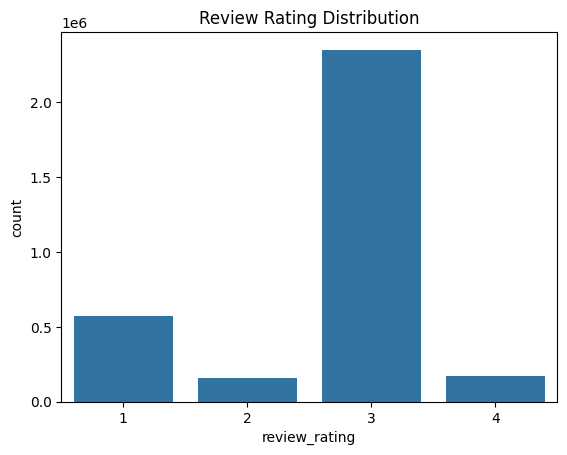

In [ ]:
#review rating distribution
sns.countplot(x='review_rating', data=pool)
plt.title("Review Rating Distribution")
plt.show()

In [ ]:
# Drop rows missing anything we need
pool = pool.dropna(subset=['delta_t', 'i', 'review_rating', 'y']).copy()

In [ ]:
# remove first review as it has no pre rev_history
len_before_first_reviews = len(pool)

pool = pool[pool['i'] > 1].copy()

print(f"Removed {len_before_first_reviews - len(pool):,} 'first review' rows.")
print(f"Remaining : {len(pool):,}")

Removed 321,507 'first review' rows.
Remaining : 2,928,294


In [ ]:
# reviews that happened before the current review
pool['past_reviews_count'] = pool['i'] - 1
print(pool['past_reviews_count'].describe())

count    2.928294e+06
mean     1.226166e+01
std      1.563889e+01
min      1.000000e+00
25%      3.000000e+00
50%      6.000000e+00
75%      1.500000e+01
max      2.090000e+02
Name: past_reviews_count, dtype: float64


In [ ]:
pool = pool.rename(
    columns={'delta_t': 'days_since_last_review'}
)

In [19]:
# Calc the average rating from previous reviews only avoiding data leakege from make it equal to current_rev
def compute_avg_score(history):
    if pd.isna(history) or not history:
        return np.nan

    ratings = [int(x) for x in history.split(',') if x]
    return np.mean(ratings) if ratings else np.nan

pool['avg_score'] = pool['r_history'].apply(compute_avg_score)

In [ ]:
print(f"NaNs in avg_score: {pool['avg_score'].isna().sum()}")

NaNs in avg_score: 0


#####find data-driven values for the multipliers used to calculate the predicted interval days

In [18]:
# derive_interval_multipliers

df = pool.sort_values(['card_id', 'i']).copy()

df['next_interval'] = df.groupby('card_id')['days_since_last_review'].shift(-1)
df['current_interval'] = df['days_since_last_review']

valid = df[
    (df['review_rating'] > 1) &
    (df['current_interval'] > 0) &
    (df['next_interval'] > 0)
].copy()

valid['growth_ratio'] = valid['next_interval'] / valid['current_interval']

# Filter out extreme outliers  — cap at a reasonable range for interval growth
valid = valid[(valid['growth_ratio'] > 0.5) & (valid['growth_ratio'] < 10)]

print(valid['growth_ratio'].describe())
print()
print(f"Median growth ratio: {valid['growth_ratio'].median():.2f}")
print(f"25th percentile:     {valid['growth_ratio'].quantile(0.25):.2f}")
print(f"75th percentile:     {valid['growth_ratio'].quantile(0.75):.2f}")


# Split by "confidence" the same way predictor.py does — using avg_score


moderate_conf = valid[(valid['avg_score'] >= 2.5) & (valid['avg_score'] < 4.0)]
high_conf = valid[valid['avg_score'] >= 4.0]

print()
print(f"Moderate-confidence transitions : {len(moderate_conf):,}")
print(f"Median growth ratio: {moderate_conf['growth_ratio'].median():.2f}")
print()
print(f"High-confidence transitions (avg_score >= 4.0): {len(high_conf):,}")
print(f"Median growth ratio: {high_conf['growth_ratio'].median():.2f}")


count    2.097635e+06
mean     2.597039e+00
std      1.355563e+00
min      5.000151e-01
25%      1.657690e+00
50%      2.380443e+00
75%      3.053799e+00
max      9.999804e+00
Name: growth_ratio, dtype: float64

Median growth ratio: 2.38
25th percentile:     1.66
75th percentile:     3.05

Moderate-confidence transitions : 1,087,701
Median growth ratio: 2.55

High-confidence transitions (avg_score >= 4.0): 59,205
Median growth ratio: 3.11


In [ ]:
# Inspect upper percentiles to identify a reasonable interval cap
print(valid['next_interval'].quantile(0.75))   
print(valid['next_interval'].quantile(0.90))

62.186350000000004
207.1466


In [ ]:
pool['overdue_ratio'] = pool['days_since_last_review'] / (pool['past_reviews_count'] + 1)

In [ ]:
# Convert the dataset target:
# y = 0 -> forgot -> needs_review = 1
pool['needs_review'] = 1 - pool['y']

In [ ]:
features = ['past_reviews_count', 'avg_score', 'days_since_last_review', 'overdue_ratio']

In [ ]:
pool[features + ['needs_review', 'card_id']].head()

,past_reviews_count,avg_score,days_since_last_review,overdue_ratio,needs_review,card_id
1,1,3.0,2.5945,1.297250,0,1630607654030
2,2,3.0,18.1045,6.034833,0,1630607654030
3,3,3.0,199.1413,49.785325,0,1630607654030
5,1,3.0,1.9196,0.959800,0,1630607654032
6,2,3.0,13.4792,4.493067,0,1630607654032


### Card-Level Train / Validation / Test Split

Split by **unique card**, not by row as a card has multiple review rows, and splitting by row would let
the same card appear in both train and test, leaking information

In [ ]:
from sklearn.model_selection import train_test_split

unique_cards = pool['card_id'].unique()
train_cards_all, test_cards = train_test_split(unique_cards, test_size=0.2, random_state=42)
train_cards, val_cards = train_test_split(train_cards_all, test_size=0.2, random_state=42)

#train_cards_all is our source to take the cards

test_df = pool[pool['card_id'].isin(test_cards)]
val_df = pool[pool['card_id'].isin(val_cards)]

X_test, y_test = test_df[features], test_df['needs_review']
X_val, y_val = val_df[features], val_df['needs_review']


In [ ]:
#just to make sure it worked right
overlap = set(train_cards_all) & set(test_cards)

print(f"Overlapping cards: {len(overlap)}")

Overlapping cards: 0


evaluate how model performance changes as the training data size increases to identify when additional data stops providing meaningful improvements

In [ ]:
#keeping the test set away from validtion

train_cards, val_cards = train_test_split(
    train_cards_all,
    test_size=0.2,
    random_state=42
)

# Validation set
val_df = pool[pool['card_id'].isin(val_cards)]

X_val = val_df[features]
y_val = val_df['needs_review']

print(f"Training-pool cards: {len(train_cards):,}")
print(f"Validation cards: {len(val_cards):,}")
print(f"Validation set: {len(val_df):,} rows from {val_df['card_id'].nunique():,} cards")

Training-pool cards: 191,686
Validation cards: 47,922
Validation set: 471,288 rows from 47,922 cards


In [ ]:
#just making sure no card repeats  in the diff sets
train_val_overlap = set(train_cards) & set(val_cards)
train_test_overlap = set(train_cards) & set(test_cards)
val_test_overlap = set(val_cards) & set(test_cards)

print(f"Train/Validation overlap: {len(train_val_overlap)}")
print(f"Train/Test overlap: {len(train_test_overlap)}")
print(f"Validation/Test overlap: {len(val_test_overlap)}")

Train/Validation overlap: 0
Train/Test overlap: 0
Validation/Test overlap: 0


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import recall_score


#from the train_cards not the tarin_cards_all
card_sample_sizes = [2_000, 5_000, 10_000, 20_000, 40_000]
results = []

# Shuffle training cards once
shuffled_cards = pd.Series(train_cards).sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

for n_cards in card_sample_sizes:
    n_cards = min(n_cards, len(shuffled_cards))

    # Cumulative cards
    sampled_cards = shuffled_cards.iloc[:n_cards]

    # All review rows belonging to these cards
    train_df = pool[pool['card_id'].isin(sampled_cards)]

    X_train = train_df[features]
    y_train = train_df['needs_review']

    model = RandomForestClassifier(
        max_depth=6,
        n_estimators=50,
        class_weight='balanced',
        random_state=42
    )

    model.fit(X_train, y_train)

    # Evaluate ONLY on validation
    preds = model.predict(X_val)

    recall = recall_score(
        y_val,
        preds,
        pos_label=1
    )

    results.append({
        "n_cards": n_cards,
        "n_rows": len(train_df),
        "recall": recall
    })

    print(f"Training Cards : {n_cards:,}")
    print(f"Training Rows  : {len(train_df):,}")
    print(f"Recall         : {recall:.3f}")

results_df = pd.DataFrame(results)
results_df

Training Cards : 2,000
Training Rows  : 20,565
Recall         : 0.703
Training Cards : 5,000
Training Rows  : 48,906
Recall         : 0.721
Training Cards : 10,000
Training Rows  : 97,949
Recall         : 0.727
Training Cards : 20,000
Training Rows  : 196,253
Recall         : 0.728
Training Cards : 40,000
Training Rows  : 390,562
Recall         : 0.729


,n_cards,n_rows,recall
0,2000,20565,0.703337
1,5000,48906,0.721496
2,10000,97949,0.727374
3,20000,196253,0.727675
4,40000,390562,0.728775


Test different training sizes with multiple random seeds  
to check whether the validation recall is stable or depends on the sampled cards.

In [ ]:
card_sample_sizes = [5_000, 10_000, 20_000, 40_000]
seeds = [42, 123, 456]

results = []

for n_cards in card_sample_sizes:

    for seed in seeds:
        shuffled_cards = pd.Series(train_cards).sample(
            frac=1,
            random_state=seed
        ).reset_index(drop=True)

        sampled_cards = shuffled_cards.iloc[:n_cards]

        train_df = pool[pool['card_id'].isin(sampled_cards)]

        X_train = train_df[features]
        y_train = train_df['needs_review']

        model = RandomForestClassifier(
            max_depth=6,
            n_estimators=50,
            class_weight='balanced',
            random_state=42
        )

        model.fit(X_train, y_train)

        # Evaluate on the SAME validation set
        preds = model.predict(X_val)

        recall = recall_score(y_val,preds,pos_label=1)

        results.append({
            "n_cards": n_cards,
            "seed": seed,
            "n_rows": len(train_df),
            "recall": recall
        })

        print(f"Training Cards : {n_cards:,}")
        print(f"Seed : {seed :,}")
        print(f"Recall         : {recall:.3f}")

results_df = pd.DataFrame(results)

Training Cards : 5,000
Seed : 42
Recall         : 0.721
Training Cards : 5,000
Seed : 123
Recall         : 0.715
Training Cards : 5,000
Seed : 456
Recall         : 0.710
Training Cards : 10,000
Seed : 42
Recall         : 0.727
Training Cards : 10,000
Seed : 123
Recall         : 0.737
Training Cards : 10,000
Seed : 456
Recall         : 0.720
Training Cards : 20,000
Seed : 42
Recall         : 0.728
Training Cards : 20,000
Seed : 123
Recall         : 0.730
Training Cards : 20,000
Seed : 456
Recall         : 0.720
Training Cards : 40,000
Seed : 42
Recall         : 0.729
Training Cards : 40,000
Seed : 123
Recall         : 0.719
Training Cards : 40,000
Seed : 456
Recall         : 0.713


In [ ]:
# Summarize recall across seeds to compare average performance and stability.
summary = (
    results_df
    .groupby("n_cards")["recall"]
    .agg(["mean", "std", "min", "max"])
    .reset_index()
)

summary

,n_cards,mean,std,min,max
0,5000,0.715251,0.005972,0.709595,0.721496
1,10000,0.728225,0.008718,0.719964,0.737337
2,20000,0.725702,0.005483,0.719506,0.729927
3,40000,0.720029,0.008165,0.712606,0.728775


In [ ]:
#now we need to select the model

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report

FINAL_N_CARDS = 20_000

shuffled_cards = pd.Series(train_cards).sample(frac=1, random_state=42).reset_index(drop=True)
final_train_cards = shuffled_cards.iloc[:FINAL_N_CARDS]
train_df = pool[pool['card_id'].isin(final_train_cards)]

X_train, y_train = train_df[features], train_df['needs_review']

candidates = {
    "LogisticRegression": LogisticRegression(class_weight='balanced', max_iter=1000),
    "DecisionTree": DecisionTreeClassifier(max_depth=6, class_weight='balanced', random_state=42),
    "RandomForest": RandomForestClassifier(
        max_depth=6, n_estimators=50, class_weight='balanced', random_state=42
    ),
}

model_comparison_results = []
for name, model in candidates.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_val)
    recall = recall_score(y_val, preds, pos_label=1)
    model_comparison_results.append({"model": name, "val_recall": recall})
    print(f"\n{name}")
    print(f"Validation recall : {recall:.3f}")
    print(classification_report(y_val, preds))

pd.DataFrame(model_comparison_results)


LogisticRegression
Validation recall : 0.664
              precision    recall  f1-score   support

           0       0.91      0.62      0.74    394905
           1       0.25      0.66      0.37     76383

    accuracy                           0.63    471288
   macro avg       0.58      0.64      0.55    471288
weighted avg       0.80      0.63      0.68    471288


DecisionTree
Validation recall : 0.689
              precision    recall  f1-score   support

           0       0.91      0.62      0.74    394905
           1       0.26      0.69      0.38     76383

    accuracy                           0.63    471288
   macro avg       0.59      0.66      0.56    471288
weighted avg       0.81      0.63      0.68    471288


RandomForest
Validation recall : 0.728
              precision    recall  f1-score   support

           0       0.92      0.59      0.72    394905
           1       0.26      0.73      0.38     76383

    accuracy                           0.61    471288
  

,model,val_recall
0,LogisticRegression,0.664232
1,DecisionTree,0.688700
2,RandomForest,0.727675


Decision Threshold Selection


In [ ]:
from sklearn.metrics import precision_score, accuracy_score, fbeta_score

final_model = RandomForestClassifier(
    max_depth=6, n_estimators=50, class_weight='balanced', random_state=42
)
final_model.fit(X_train, y_train)

val_probs = final_model.predict_proba(X_val)[:, 1]
thresholds = [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60]

threshold_results = []
for t in thresholds:
    preds = (val_probs >= t).astype(int)
    threshold_results.append({
        "threshold": t,
        "recall": recall_score(y_val, preds, pos_label=1),
        "precision": precision_score(y_val, preds, pos_label=1, zero_division=0),
        "f1": fbeta_score(y_val, preds, beta=1, zero_division=0),
        "f2": fbeta_score(y_val, preds, beta=2, zero_division=0),
    })

threshold_df = pd.DataFrame(threshold_results)
threshold_df

,threshold,recall,precision,f1,f2
0,0.30,0.917770,0.206936,0.337723,0.544022
1,0.35,0.909679,0.209766,0.340918,0.545590
2,0.40,0.877106,0.219436,0.351047,0.548391
3,0.45,0.827318,0.232873,0.363444,0.547700
4,0.50,0.727675,0.256217,0.378991,0.531921
5,0.55,0.628635,0.277273,0.384815,0.501527
6,0.60,0.526413,0.296796,0.379581,0.455875


In [ ]:
FINAL_THRESHOLD = 0.45

In [ ]:
from sklearn.metrics import average_precision_score
final_cards = pd.concat([pd.Series(final_train_cards), pd.Series(val_cards)])
final_train_df = pool[pool['card_id'].isin(final_cards)]

X_final_train = final_train_df[features]
y_final_train = final_train_df['needs_review']

final_model = RandomForestClassifier(
    max_depth=6, n_estimators=50, class_weight='balanced', random_state=42
)
final_model.fit(X_final_train, y_final_train)

test_probs = final_model.predict_proba(X_test)[:, 1]
test_preds = (test_probs >= FINAL_THRESHOLD).astype(int)



print(f"Threshold: {FINAL_THRESHOLD}")
print(f"Recall:    {recall_score(y_test, test_preds):.3f}")
print(f"Precision: {precision_score(y_test, test_preds, zero_division=0):.3f}")
print(f"F2 Score:  {fbeta_score(y_test, test_preds, beta=2):.3f}")
print(f"PR-AUC:    {average_precision_score(y_test, test_probs):.3f}")



Threshold: 0.45
Recall:    0.832
Precision: 0.231
F2 Score:  0.548
PR-AUC:    0.327



In [ ]:
import joblib, os

joblib.dump(final_model, 'retention_model.pkl')
print(f"Model size: {os.path.getsize('retention_model.pkl') / 1024:.1f} KB")

Model size: 513.3 KB
